# Yelp Review Prediction

This notebook studies a simple question:

**Can a business's Yelp reviews in its first 30 days predict its average rating over the rest of its first year?**

The workflow is:

1. Load Yelp business and review data
2. Filter to the chosen state and cohort year
3. Define an **early** window and a **future** window
4. Aggregate review-level data into **one row per business**
5. Train regression models
6. Compare results and interpret what matters most


## 1. Project configuration

All key choices are stored as constants below so they can be changed later for robustness checks.
For example, you can change the state, cohort year, or window sizes without rewriting the notebook.


In [ ]:
# =========================
# Project configuration
# =========================

STATE = "PA"
COHORT_YEAR = 2015

# Early window: first 30 days after the business's first review
EARLY_WINDOW_DAYS = 30

# Future window: day 31 through day 365 after the business's first review
FUTURE_WINDOW_START_DAY = EARLY_WINDOW_DAYS + 1
FUTURE_WINDOW_END_DAY = 365

# Minimum review thresholds to keep a business in the final modeling dataset
MIN_EARLY_REVIEWS = 2
MIN_FUTURE_REVIEWS = 3

## 2. Load the Yelp data

We only need two files for this version of the project:

- `business.json` to identify Florida businesses
- `review.json` to get review dates, stars, and text

We keep only the columns needed for the analysis.


In [2]:
import pandas as pd

# Load the Yelp files (JSON lines format)
business_df = pd.read_json("yelp_dataset/yelp_academic_dataset_business.json", lines=True)
review_df = pd.read_json("yelp_dataset/yelp_academic_dataset_review.json", lines=True)

# Keep only the columns needed for this project
business_df = business_df[
    ["business_id", "state", "is_open", "review_count", "stars", "categories"]
]

review_df = review_df[
    ["review_id", "user_id", "business_id", "stars", "date", "text", "useful", "funny", "cool"]
]

# Convert review date from string to datetime
review_df["date"] = pd.to_datetime(review_df["date"])

print("Business shape:", business_df.shape)
print("Review shape:", review_df.shape)

business_df.head()

Business shape: (150346, 6)
Review shape: (6990280, 9)


,business_id,state,is_open,review_count,stars,categories
0,Pns2l4eNsfO8kk83dixA6A,CA,0,7,5.0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,MO,1,15,3.0,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,AZ,0,22,3.5,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,PA,1,80,4.0,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,PA,1,13,4.5,"Brewpubs, Breweries, Food"


## 3. Filter to the chosen state

This step keeps only businesses in the selected state and only reviews belonging to those businesses.


In [3]:
# Keep only businesses in the selected state
state_business_df = business_df[business_df["state"] == STATE].copy()

# Keep only reviews written for businesses in the selected state
state_review_df = review_df[
    review_df["business_id"].isin(state_business_df["business_id"])
].copy()

print("Businesses in state:", state_business_df.shape)
print("Reviews in state:", state_review_df.shape)

Businesses in state: (5203, 6)
Reviews in state: (348856, 9)


## 4. Define the 2015 business cohort

For each business, we find the date of its **first review**.
We then keep only businesses whose first review occurred in the selected cohort year.

This first review date becomes the business's time zero, or **t0**.


In [4]:
# Find the first review date for each business in the selected state
first_review_df = (
    state_review_df.groupby("business_id", as_index=False)["date"]
    .min()
    .rename(columns={"date": "first_review_date"})
)

# Keep only businesses whose first review date is in the chosen cohort year
cohort_business_df = first_review_df[
    first_review_df["first_review_date"].dt.year == COHORT_YEAR
].copy()

# Filter both the business table and the review table to this cohort
state_business_cohort_df = state_business_df[
    state_business_df["business_id"].isin(cohort_business_df["business_id"])
].copy()

state_review_cohort_df = state_review_df[
    state_review_df["business_id"].isin(cohort_business_df["business_id"])
].copy()

print("Cohort businesses:", state_business_cohort_df.shape)
print("Cohort reviews:", state_review_cohort_df.shape)

Cohort businesses: (424, 6)
Cohort reviews: (17941, 9)


## 5. Label reviews as early, future, or outside the study window

For each review, we compute how many days it occurred after the business's first review.

Window definitions:

- **early**: day 0 through day 30
- **future**: day 31 through day 365
- **other**: anything outside those windows

Later, we will keep only the `early` and `future` reviews for analysis.


In [5]:
# Attach each business's first review date to every review in the cohort
state_review_cohort_df = state_review_cohort_df.merge(
    cohort_business_df,
    on="business_id",
    how="left"
)

# Compute the number of days since the business's first review
state_review_cohort_df["days_since_first_review"] = (
    state_review_cohort_df["date"] - state_review_cohort_df["first_review_date"]
).dt.days

# Initialize all reviews as "other"
state_review_cohort_df["window"] = "other"

# Label early reviews
state_review_cohort_df.loc[
    state_review_cohort_df["days_since_first_review"].between(0, EARLY_WINDOW_DAYS),
    "window"
] = "early"

# Label future reviews
state_review_cohort_df.loc[
    state_review_cohort_df["days_since_first_review"].between(
        FUTURE_WINDOW_START_DAY,
        FUTURE_WINDOW_END_DAY
    ),
    "window"
] = "future"

print(state_review_cohort_df["window"].value_counts())

window
other     12738
future     4015
early      1188
Name: count, dtype: int64


## 6. Build the business-level modeling table

The raw Yelp data is review-level, but the model should work at the **business level**.

So we create **one row per business**.

### Early-window features
- `early_review_count`: number of early reviews
- `early_avg_rating`: average early star rating
- `early_rating_std`: variability in early ratings
- `early_avg_review_length`: average number of words in early reviews

### Future target
- `future_review_count`: number of future reviews
- `future_avg_rating`: average future star rating


In [6]:
# Keep only reviews that are actually part of the study windows
analysis_reviews_df = state_review_cohort_df[
    state_review_cohort_df["window"].isin(["early", "future"])
].copy()

# Split into early and future subsets
early_reviews_df = analysis_reviews_df[
    analysis_reviews_df["window"] == "early"
].copy()

future_reviews_df = analysis_reviews_df[
    analysis_reviews_df["window"] == "future"
].copy()

# Sort early reviews so "first" is truly the earliest review if needed later
early_reviews_df = early_reviews_df.sort_values(["business_id", "date"]).copy()
future_reviews_df = future_reviews_df.sort_values(["business_id", "date"]).copy()

# Create a simple text feature:
# number of words in each early review
early_reviews_df["review_length"] = (
    early_reviews_df["text"].fillna("").str.split().str.len()
)

# Aggregate early-window review information to one row per business
early_features_df = (
    early_reviews_df.groupby("business_id")
    .agg(
        early_review_count=("review_id", "count"),
        early_avg_rating=("stars", "mean"),
        early_rating_std=("stars", "std"),
        early_avg_review_length=("review_length", "mean")
    )
    .reset_index()
)

# Aggregate future-window review information to one row per business
future_target_df = (
    future_reviews_df.groupby("business_id")
    .agg(
        future_review_count=("review_id", "count"),
        future_avg_rating=("stars", "mean")
    )
    .reset_index()
)

# Merge predictors and target
model_df = early_features_df.merge(
    future_target_df,
    on="business_id",
    how="inner"
)

# If a business has only one early review, the std is NaN
# Fill it with 0 because there is no variation with one value
model_df["early_rating_std"] = model_df["early_rating_std"].fillna(0)

# Keep only businesses with enough reviews in both windows
model_df = model_df[
    (model_df["early_review_count"] >= MIN_EARLY_REVIEWS) &
    (model_df["future_review_count"] >= MIN_FUTURE_REVIEWS)
].copy()

print("Final modeling dataset shape:", model_df.shape)
model_df.head()

Final modeling dataset shape: (109, 7)


,business_id,early_review_count,early_avg_rating,early_rating_std,early_avg_review_length,future_review_count,future_avg_rating
3,0JALnjetn1qNqJL2GYI6mg,2,5.000000,0.000000,75.500000,7,4.428571
5,0RxU5OglQyPVtLKC1LPgsA,15,4.866667,0.516398,63.400000,116,4.655172
7,1NkWcNHFxi2YaV5yjUlJUQ,2,5.000000,0.000000,88.500000,3,4.666667
8,1pd4VYTww1UWDVai2r2RKg,18,3.444444,1.503808,100.666667,65,3.461538
12,2GRe6cUrQRfA1mtzS1DNkA,2,5.000000,0.000000,48.500000,7,5.000000


## 7. Quick sanity checks

Before modeling, it is helpful to check:

- the size of the final dataset
- summary statistics
- missing values
- whether the target distribution looks reasonable
- whether early average rating appears related to future average rating


In [7]:
import matplotlib.pyplot as plt

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

Model dataset shape: (109, 7)

Columns:
['business_id', 'early_review_count', 'early_avg_rating', 'early_rating_std', 'early_avg_review_length', 'future_review_count', 'future_avg_rating']

Summary statistics:
       early_review_count  early_avg_rating  early_rating_std  \
count          109.000000        109.000000        109.000000   
mean             7.449541          4.204428          0.694150   
std              9.271108          1.038973          0.719905   
min              2.000000          1.000000          0.000000   
25%              2.000000          3.750000          0.000000   
50%              4.000000          4.666667          0.547723   
75%              9.000000          5.000000          1.305204   
max             68.000000          5.000000          2.121320   

       early_avg_review_length  future_review_count  future_avg_rating  
count               109.000000           109.000000         109.000000  
mean                103.445828            30.733945       

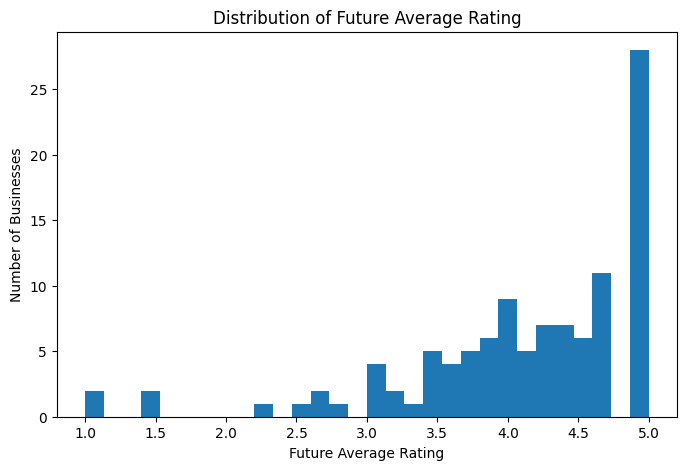

In [8]:
# Distribution of the target: future average rating
plt.figure(figsize=(8, 5))
plt.hist(model_df["future_avg_rating"], bins=30)
plt.xlabel("Future Average Rating")
plt.ylabel("Number of Businesses")
plt.title("Distribution of Future Average Rating")
plt.show()

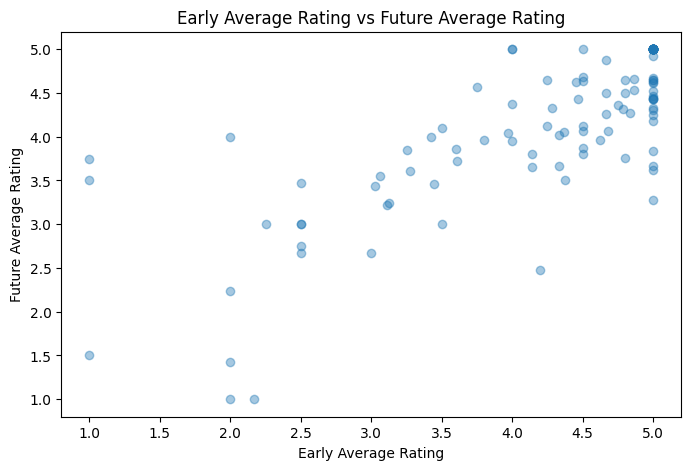

In [9]:
# Relationship between the main predictor and the target
plt.figure(figsize=(8, 5))
plt.scatter(model_df["early_avg_rating"], model_df["future_avg_rating"], alpha=0.4)
plt.xlabel("Early Average Rating")
plt.ylabel("Future Average Rating")
plt.title("Early Average Rating vs Future Average Rating")
plt.show()

In [10]:
# Correlations among the numeric variables
corr = model_df[[
    "early_review_count",
    "early_avg_rating",
    "early_rating_std",
    "early_avg_review_length",
    "future_review_count",
    "future_avg_rating"
]].corr()

print(corr["future_avg_rating"].sort_values(ascending=False))

future_avg_rating          1.000000
early_avg_rating           0.765769
future_review_count       -0.014276
early_review_count        -0.098487
early_avg_review_length   -0.380909
early_rating_std          -0.579938
Name: future_avg_rating, dtype: float64


In [11]:
# Diagnostics: how many businesses survive each stage?
print("Businesses with early features:", early_features_df.shape[0])
print("Businesses with future target:", future_target_df.shape[0])
print(
    "Businesses after merge:",
    early_features_df.merge(future_target_df, on="business_id", how="inner").shape[0]
)
print("Businesses after min-review filters:", model_df.shape[0])

Businesses with early features: 424
Businesses with future target: 348
Businesses after merge: 348
Businesses after min-review filters: 109


## 8. Train/test split and baseline

We use a random 80/20 train/test split.

The baseline model predicts the **mean future rating in the training set** for every test business.
This gives us a simple reference point.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
import numpy as np

# Features used in the main model
feature_cols = [
    "early_review_count",
    "early_avg_rating",
    "early_rating_std",
    "early_avg_review_length"
]

X = model_df[feature_cols]
y = model_df["future_avg_rating"]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87, 4)
X_test shape: (22, 4)
y_train shape: (87,)
y_test shape: (22,)


In [13]:
# Baseline: always predict the training-set mean
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline results")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R^2:", baseline_r2)

Baseline results
MAE: 0.5868111642228903
RMSE: 0.8084597355747546
R^2: -0.03601562642379452


## 9. Linear regression

This is the main predictive model. It estimates a linear relationship between the early business features and the future average rating.


In [14]:
# Fit the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
lr_pred = lr_model.predict(X_test)

# Evaluate performance
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R^2:", lr_r2)

Linear Regression results
MAE: 0.3864272409705947
RMSE: 0.5369650593383136
R^2: 0.5429733038270075


In [15]:
# Display the linear regression coefficients
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
1,early_avg_rating,0.642555
3,early_avg_review_length,-0.000086
0,early_review_count,-0.000833
2,early_rating_std,-0.072964


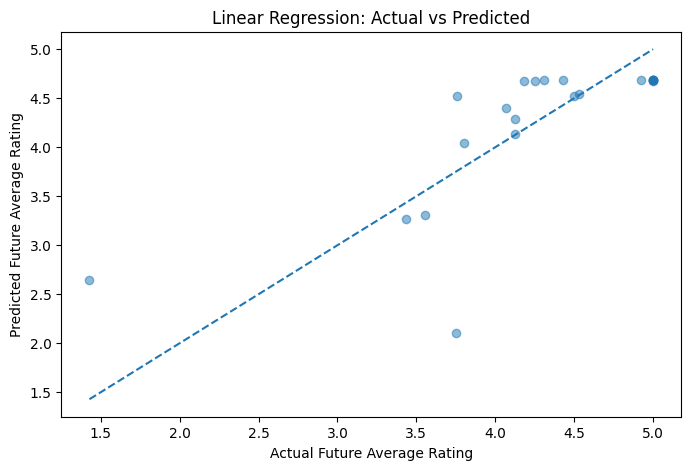

In [16]:
# Predicted vs actual values for linear regression
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_pred, alpha=0.5)

# Add the diagonal line for perfect predictions
min_val = min(y_test.min(), lr_pred.min())
max_val = max(y_test.max(), lr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Future Average Rating")
plt.ylabel("Predicted Future Average Rating")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

## 10. Ridge regression

Ridge regression is a regularized version of linear regression.
It is useful as a comparison model to check whether mild regularization improves performance.


In [17]:
# Fit the ridge regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predict on the test set
ridge_pred = ridge_model.predict(X_test)

# Evaluate performance
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression results")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R^2:", ridge_r2)

Ridge Regression results
MAE: 0.38310691865837626
RMSE: 0.5318664754253117
R^2: 0.5516112072810775


In [18]:
# Display the ridge regression coefficients
ridge_coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": ridge_model.coef_
}).sort_values("coefficient", ascending=False)

ridge_coef_df

,feature,coefficient
1,early_avg_rating,0.629614
3,early_avg_review_length,-0.000151
0,early_review_count,-0.000694
2,early_rating_std,-0.081849


## 11. Ablation study

The goal here is to see how much predictive signal comes from:

- **Model A**: only `early_avg_rating`
- **Model B**: rating-based features
- **Model C**: all current features

This helps show whether the extra features meaningfully improve performance.


In [19]:
# Reuse the same train/test indices for fair model comparison
train_idx = X_train.index
test_idx = X_test.index

feature_sets = {
    "Model A: early_avg_rating only": ["early_avg_rating"],
    "Model B: rating features": ["early_review_count", "early_avg_rating", "early_rating_std"],
    "Model C: all current features": ["early_review_count", "early_avg_rating", "early_rating_std", "early_avg_review_length"]
}

results = []

for model_name, cols in feature_sets.items():
    X_train_sub = model_df.loc[train_idx, cols]
    X_test_sub = model_df.loc[test_idx, cols]
    y_train_sub = model_df.loc[train_idx, "future_avg_rating"]
    y_test_sub = model_df.loc[test_idx, "future_avg_rating"]

    model = LinearRegression()
    model.fit(X_train_sub, y_train_sub)
    pred = model.predict(X_test_sub)

    mae = mean_absolute_error(y_test_sub, pred)
    rmse = np.sqrt(mean_squared_error(y_test_sub, pred))
    r2 = r2_score(y_test_sub, pred)

    results.append({
        "model": model_name,
        "features": ", ".join(cols),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,model,features,MAE,RMSE,R2
2,Model C: all current features,"early_review_count, early_avg_rating, early_ra...",0.386427,0.536965,0.542973
1,Model B: rating features,"early_review_count, early_avg_rating, early_ra...",0.386919,0.537490,0.542080
0,Model A: early_avg_rating only,early_avg_rating,0.399237,0.561568,0.500133


## 12. Interpretation and takeaway (EXAMPLE)

1. The baseline model, which predicts the mean future rating for every business, performed much worse than the regression models. The baseline had an MAE of about 0.730, an RMSE of about 0.953, and an R^2 slightly below zero, while linear regression reduced the error substantially and achieved an R^2 of about 0.504. This means the early review features contain real predictive signal and are not just matching what a naive average would do.

2. Linear regression performed clearly better than the baseline, with an MAE of about 0.494, an RMSE of about 0.662, and an R^2 of about 0.504. Ridge regression produced almost identical results, which suggests the feature set is already fairly stable and that regularization does not change the overall conclusion much. In other words, the relationship between early review behavior and later rating is strong enough to be captured well even by a simple linear model.

3. Early average rating is doing most of the work. The model using only early average rating already achieved an R^2 of about 0.502. Adding early review count and early rating standard deviation increased performance only slightly, and adding average review length improved it by almost nothing. This suggests that a business’s average rating in its first 30 days is already the dominant signal for predicting its average rating over the rest of its first year.

**A business’s average rating in its first 30 days is already a strong predictor of its average rating over the rest of its first year.**